# Notebook 03 — XGBoost Model
## Employee Attrition Prediction

**Project:** XGBoost vs Random Forest — Comparative Analysis  
**Dataset:** IBM HR Analytics (preprocessed by Notebook 01)

---

### Notebook outline
1. Imports & configuration
2. Load preprocessed data from Notebook 01
3. Data verification
4. Baseline XGBoost model
5. Hyperparameter tuning (RandomizedSearchCV + ImbPipeline)
6. Tuned model evaluation
7. Confusion matrix & ROC / PR curves
8. Feature importance analysis
9. Threshold optimisation
10. Save model & results summary

## 1. Imports & Configuration

In [1]:
import warnings
import os
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve,
    precision_recall_curve, average_precision_score,
)
from sklearn.inspection import permutation_importance

# ImbPipeline wraps SMOTE inside CV folds to prevent data leakage
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from scipy.stats import randint, uniform

import joblib

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
RANDOM_STATE = 42
FIGURES_DIR  = '../figures'
MODELS_DIR   = '../models'
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR,  exist_ok=True)

print('All libraries loaded successfully.')
print(f'XGBoost version: {xgb.__version__}')

All libraries loaded successfully.
XGBoost version: 3.1.3


## 2. Load Preprocessed Data from Notebook 01

Loading the same train/test splits used by the Random Forest notebook — ensuring both models are evaluated on **identical data** for a fair comparison.

- `X_train.csv` / `y_train.csv` — SMOTE-balanced, used to **train** the final model  
- `X_train_orig.csv` / `y_train_orig.csv` — original unbalanced, used for **cross-validation** to avoid leakage  
- `X_test.csv` / `y_test.csv` — held-out test set, never touched during training

In [2]:
PROCESSED_DIR = '../data/processed'

# SMOTE-balanced splits — for model training
X_train = pd.read_csv(os.path.join(PROCESSED_DIR, 'X_train.csv'))
y_train = pd.read_csv(os.path.join(PROCESSED_DIR, 'y_train.csv')).squeeze()

# Original unbalanced splits — for cross-validation only
X_train_orig = pd.read_csv(os.path.join(PROCESSED_DIR, 'X_train_orig.csv'))
y_train_orig = pd.read_csv(os.path.join(PROCESSED_DIR, 'y_train_orig.csv')).squeeze()

# Test set — never touched during training
X_test = pd.read_csv(os.path.join(PROCESSED_DIR, 'X_test.csv'))
y_test = pd.read_csv(os.path.join(PROCESSED_DIR, 'y_test.csv')).squeeze()

print('Data loaded successfully from data/processed/')
print(f'X_train (SMOTE)    : {X_train.shape}')
print(f'X_train (original) : {X_train_orig.shape}')
print(f'X_test             : {X_test.shape}')
print(f'y_train (SMOTE)    : {y_train.shape}')
print(f'y_train (original) : {y_train_orig.shape}')
print(f'y_test             : {y_test.shape}')

Data loaded successfully from data/processed/
X_train (SMOTE)    : (1972, 44)
X_train (original) : (1176, 44)
X_test             : (294, 44)
y_train (SMOTE)    : (1972,)
y_train (original) : (1176,)
y_test             : (294,)


## 3. Data Verification

In [3]:
print('SMOTE training class distribution:')
print(y_train.value_counts())
print(f'Attrition rate (SMOTE train)   : {y_train.mean()*100:.1f}%')

print('\nOriginal training class distribution:')
print(y_train_orig.value_counts())
print(f'Attrition rate (original train): {y_train_orig.mean()*100:.1f}%')

print(f'\nAttrition rate in test set     : {y_test.mean()*100:.1f}%')
print(f'Feature columns                : {X_train.shape[1]}')
print(f'\nSample features: {list(X_train.columns[:6])} ...')

SMOTE training class distribution:
Attrition
0    986
1    986
Name: count, dtype: int64
Attrition rate (SMOTE train)   : 50.0%

Original training class distribution:
Attrition
0    986
1    190
Name: count, dtype: int64
Attrition rate (original train): 16.2%

Attrition rate in test set     : 16.0%
Feature columns                : 44

Sample features: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'Gender'] ...


## 4. Baseline XGBoost Model

Training with default hyperparameters on SMOTE-balanced data to establish a baseline.  
Cross-validation runs on the **original unbalanced** data via `ImbPipeline` to give honest CV scores.

In [4]:
# Calculate scale_pos_weight from original training data
neg = (y_train_orig == 0).sum()
pos = (y_train_orig == 1).sum()
spw = round(neg / pos, 2)
print(f'scale_pos_weight = {neg}/{pos} = {spw}')

# Train baseline on SMOTE-balanced data
xgb_baseline = xgb.XGBClassifier(
    n_estimators    = 100,
    eval_metric     = 'logloss',
    tree_method     = 'hist',
    random_state    = RANDOM_STATE,
    n_jobs          = -1
)
xgb_baseline.fit(X_train, y_train)

y_pred_base  = xgb_baseline.predict(X_test)
y_proba_base = xgb_baseline.predict_proba(X_test)[:, 1]

print('\n=== Baseline XGBoost — Test Set ===')
print(classification_report(y_test, y_pred_base,
      target_names=['No Attrition', 'Attrition']))
print(f'ROC-AUC : {roc_auc_score(y_test, y_proba_base):.4f}')

scale_pos_weight = 986/190 = 5.19

=== Baseline XGBoost — Test Set ===
              precision    recall  f1-score   support

No Attrition       0.87      0.96      0.92       247
   Attrition       0.57      0.26      0.35        47

    accuracy                           0.85       294
   macro avg       0.72      0.61      0.63       294
weighted avg       0.82      0.85      0.83       294

ROC-AUC : 0.7511


In [5]:
# CV uses ImbPipeline on ORIGINAL data — prevents SMOTE leakage into CV folds
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

baseline_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('xgb',   xgb.XGBClassifier(
                  n_estimators=100,
                  eval_metric='logloss',
                  tree_method='hist',
                  random_state=RANDOM_STATE,
                  n_jobs=-1))
])

cv_roc = cross_val_score(baseline_pipeline, X_train_orig, y_train_orig,
                         cv=cv, scoring='roc_auc', n_jobs=-1)
cv_f1  = cross_val_score(baseline_pipeline, X_train_orig, y_train_orig,
                         cv=cv, scoring='f1', n_jobs=-1)
cv_acc = cross_val_score(baseline_pipeline, X_train_orig, y_train_orig,
                         cv=cv, scoring='accuracy', n_jobs=-1)

print('=== 5-Fold CV — Baseline XGBoost (SMOTE inside folds, original data) ===')
print(f'CV ROC-AUC : {cv_roc.mean():.4f} +/- {cv_roc.std():.4f}')
print(f'CV F1      : {cv_f1.mean():.4f}  +/- {cv_f1.std():.4f}')
print(f'CV Accuracy: {cv_acc.mean():.4f} +/- {cv_acc.std():.4f}')

=== 5-Fold CV — Baseline XGBoost (SMOTE inside folds, original data) ===
CV ROC-AUC : 0.7896 +/- 0.0340
CV F1      : 0.4616  +/- 0.0845
CV Accuracy: 0.8554 +/- 0.0173


## 5. Hyperparameter Tuning — RandomizedSearchCV

Searching over a wide parameter space using **80 random combinations** with **5-fold** stratified CV,
optimising for **ROC-AUC** — matching the same settings used in the Random Forest notebook for a fair comparison.  
Tuning uses `ImbPipeline` so SMOTE stays inside each CV fold.

In [6]:
# Param keys prefixed with 'xgb__' because estimator is a pipeline
param_dist = {
    'xgb__n_estimators'     : randint(100, 600),
    'xgb__max_depth'        : [3, 4, 5, 6, 8, 10],
    'xgb__learning_rate'    : uniform(0.01, 0.29),
    'xgb__subsample'        : uniform(0.6, 0.4),
    'xgb__colsample_bytree' : uniform(0.6, 0.4),
    'xgb__gamma'            : uniform(0, 0.5),
    'xgb__min_child_weight' : randint(1, 10),
    'xgb__reg_alpha'        : uniform(0, 1),
    'xgb__reg_lambda'       : uniform(0.5, 2),
    'xgb__scale_pos_weight' : [1, spw],
}

tune_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('xgb',   xgb.XGBClassifier(
                  eval_metric  = 'logloss',
                  tree_method  = 'hist',
                  random_state = RANDOM_STATE,
                  n_jobs       = -1))
])

xgb_search = RandomizedSearchCV(
    estimator           = tune_pipeline,
    param_distributions = param_dist,
    n_iter              = 80,
    cv                  = cv,
    scoring             = 'roc_auc',
    refit               = True,
    verbose             = 1,
    random_state        = RANDOM_STATE,
    n_jobs              = -1
)

# Fit on ORIGINAL data — SMOTE applied inside each CV fold
xgb_search.fit(X_train_orig, y_train_orig)

print('\nTuning complete!')
print(f'Best CV ROC-AUC : {xgb_search.best_score_:.4f}')
print('Best Parameters :')
for k, v in xgb_search.best_params_.items():
    print(f'  {k.replace("xgb__", "")}: {v}')

Fitting 5 folds for each of 80 candidates, totalling 400 fits

Tuning complete!
Best CV ROC-AUC : 0.8040
Best Parameters :
  colsample_bytree: 0.8788062963981071
  gamma: 0.35124204199355463
  learning_rate: 0.11425243385372899
  max_depth: 8
  min_child_weight: 7
  n_estimators: 125
  reg_alpha: 0.8101133946791808
  reg_lambda: 2.2341446371602074
  scale_pos_weight: 1
  subsample: 0.6326376721600961


## 6. Tuned Model Evaluation

In [7]:
# Best estimator is the full pipeline; extract XGBoost step for feature importance
best_pipeline = xgb_search.best_estimator_
xgb_tuned     = best_pipeline.named_steps['xgb']

y_pred_tuned  = best_pipeline.predict(X_test)
y_proba_tuned = best_pipeline.predict_proba(X_test)[:, 1]

metrics = {
    'Accuracy'  : accuracy_score(y_test, y_pred_tuned),
    'Precision' : precision_score(y_test, y_pred_tuned, zero_division=0),
    'Recall'    : recall_score(y_test, y_pred_tuned, zero_division=0),
    'F1-Score'  : f1_score(y_test, y_pred_tuned, zero_division=0),
    'ROC-AUC'   : roc_auc_score(y_test, y_proba_tuned),
    'PR-AUC'    : average_precision_score(y_test, y_proba_tuned),
}

print('=== Tuned XGBoost — Test Set Metrics ===')
for k, v in metrics.items():
    print(f'  {k:<12}: {v:.4f}')

print('\n--- Classification Report ---')
print(classification_report(y_test, y_pred_tuned,
      target_names=['No Attrition', 'Attrition']))

=== Tuned XGBoost — Test Set Metrics ===
  Accuracy    : 0.8469
  Precision   : 0.5294
  Recall      : 0.3830
  F1-Score    : 0.4444
  ROC-AUC     : 0.7708
  PR-AUC      : 0.4345

--- Classification Report ---
              precision    recall  f1-score   support

No Attrition       0.89      0.94      0.91       247
   Attrition       0.53      0.38      0.44        47

    accuracy                           0.85       294
   macro avg       0.71      0.66      0.68       294
weighted avg       0.83      0.85      0.84       294



In [8]:
# Baseline vs tuned side-by-side comparison
baseline_metrics = {
    'Accuracy'  : accuracy_score(y_test, y_pred_base),
    'Precision' : precision_score(y_test, y_pred_base, zero_division=0),
    'Recall'    : recall_score(y_test, y_pred_base, zero_division=0),
    'F1-Score'  : f1_score(y_test, y_pred_base, zero_division=0),
    'ROC-AUC'   : roc_auc_score(y_test, y_proba_base),
    'PR-AUC'    : average_precision_score(y_test, y_proba_base),
}

comparison_df = pd.DataFrame({
    'Baseline XGB' : baseline_metrics,
    'Tuned XGB'    : metrics
}).round(4)

print('=== Baseline vs Tuned Comparison ===')
print(comparison_df)

=== Baseline vs Tuned Comparison ===
           Baseline XGB  Tuned XGB
Accuracy         0.8503     0.8469
Precision        0.5714     0.5294
Recall           0.2553     0.3830
F1-Score         0.3529     0.4444
ROC-AUC          0.7511     0.7708
PR-AUC           0.4499     0.4345


## 7. Confusion Matrix & ROC / PR Curves

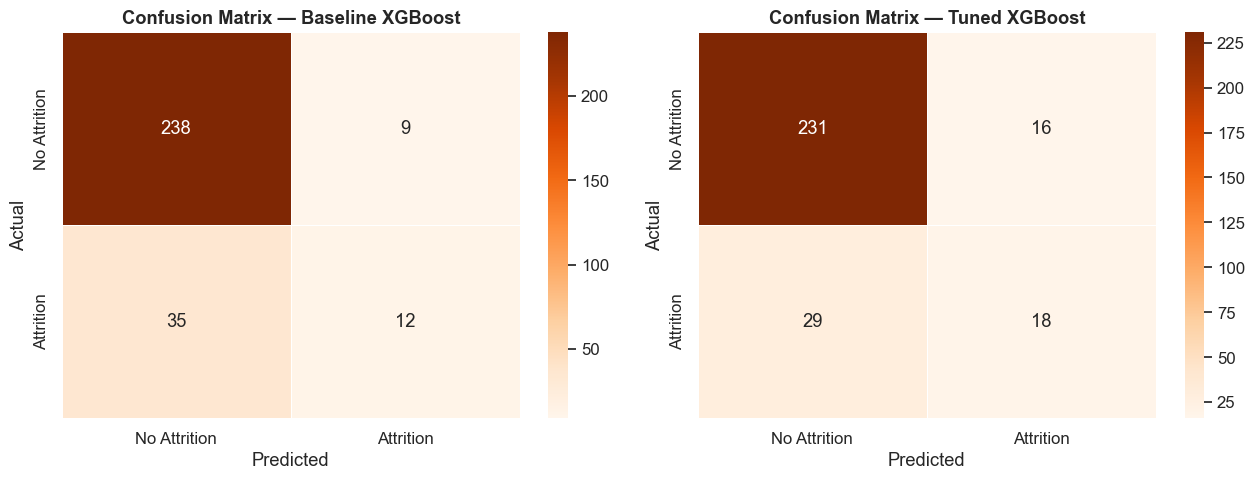

Saved: xgb_01_confusion_matrices.png


In [9]:
# Confusion matrices — baseline vs tuned
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_base, y_pred_tuned],
    ['Baseline XGBoost', 'Tuned XGBoost']
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=ax,
                xticklabels=['No Attrition', 'Attrition'],
                yticklabels=['No Attrition', 'Attrition'],
                linewidths=0.5)
    ax.set_title(f'Confusion Matrix — {title}', fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/xgb_01_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: xgb_01_confusion_matrices.png')

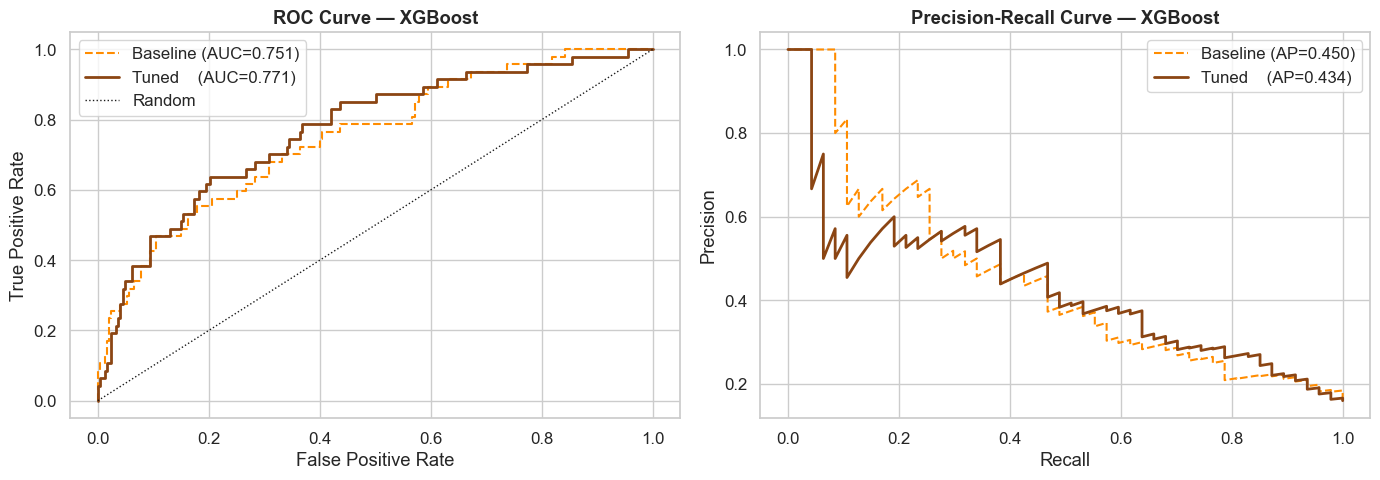

Saved: xgb_02_roc_pr_curves.png


In [10]:
# ROC & Precision-Recall curves
fpr_base,  tpr_base,  _ = roc_curve(y_test, y_proba_base)
fpr_tuned, tpr_tuned, _ = roc_curve(y_test, y_proba_tuned)

prec_base,  rec_base,  _ = precision_recall_curve(y_test, y_proba_base)
prec_tuned, rec_tuned, _ = precision_recall_curve(y_test, y_proba_tuned)

auc_base  = roc_auc_score(y_test, y_proba_base)
auc_tuned = roc_auc_score(y_test, y_proba_tuned)
ap_base   = average_precision_score(y_test, y_proba_base)
ap_tuned  = average_precision_score(y_test, y_proba_tuned)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curve
axes[0].plot(fpr_base,  tpr_base,  label=f'Baseline (AUC={auc_base:.3f})',
             lw=1.5, linestyle='--', color='darkorange')
axes[0].plot(fpr_tuned, tpr_tuned, label=f'Tuned    (AUC={auc_tuned:.3f})',
             lw=2, color='saddlebrown')
axes[0].plot([0,1],[0,1], 'k:', lw=1, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — XGBoost', fontweight='bold')
axes[0].legend()

# Precision-Recall curve
axes[1].plot(rec_base,  prec_base,  label=f'Baseline (AP={ap_base:.3f})',
             lw=1.5, linestyle='--', color='darkorange')
axes[1].plot(rec_tuned, prec_tuned, label=f'Tuned    (AP={ap_tuned:.3f})',
             lw=2, color='saddlebrown')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve — XGBoost', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/xgb_02_roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: xgb_02_roc_pr_curves.png')

## 8. Feature Importance Analysis

XGBoost provides three built-in importance types:
- **weight** — number of times a feature is used to split across all trees
- **gain** — average training loss reduction from splits using that feature (most informative)
- **cover** — average number of samples affected by splits on that feature

We also run permutation importance on the test set for a model-agnostic view.

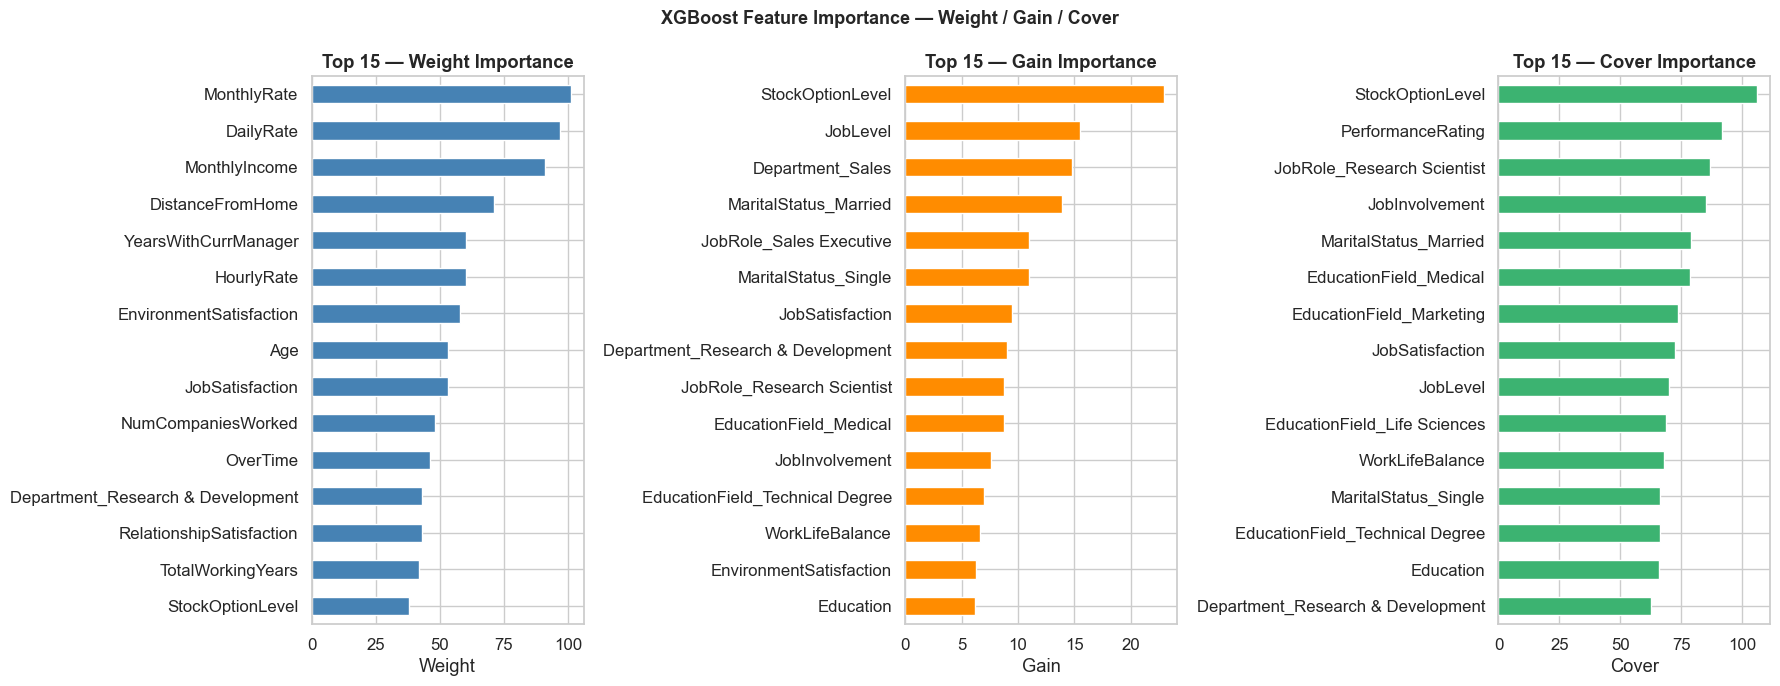

Saved: xgb_03_feature_importance_types.png

Top 10 features (Gain importance):
StockOptionLevel                     22.941563
JobLevel                             15.536782
Department_Sales                     14.775023
MaritalStatus_Married                13.860666
JobRole_Sales Executive              10.993588
MaritalStatus_Single                 10.940893
JobSatisfaction                       9.482105
Department_Research & Development     9.059785
JobRole_Research Scientist            8.793446
EducationField_Medical                8.783763


In [11]:
# XGBoost built-in importance — three types
importance_types = ['weight', 'gain', 'cover']
colors = ['steelblue', 'darkorange', 'mediumseagreen']

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for ax, imp_type, color in zip(axes, importance_types, colors):
    scores = xgb_tuned.get_booster().get_score(importance_type=imp_type)
    imp_series = pd.Series(scores).sort_values(ascending=False).head(15)
    imp_series.sort_values().plot(kind='barh', ax=ax, color=color, edgecolor='white')
    ax.set_title(f'Top 15 — {imp_type.capitalize()} Importance', fontweight='bold')
    ax.set_xlabel(imp_type.capitalize())

plt.suptitle('XGBoost Feature Importance — Weight / Gain / Cover', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/xgb_03_feature_importance_types.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: xgb_03_feature_importance_types.png')

# Use gain as primary importance series for summary
feat_imp = pd.Series(
    xgb_tuned.get_booster().get_score(importance_type='gain')
).sort_values(ascending=False)

print('\nTop 10 features (Gain importance):')
print(feat_imp.head(10).to_string())

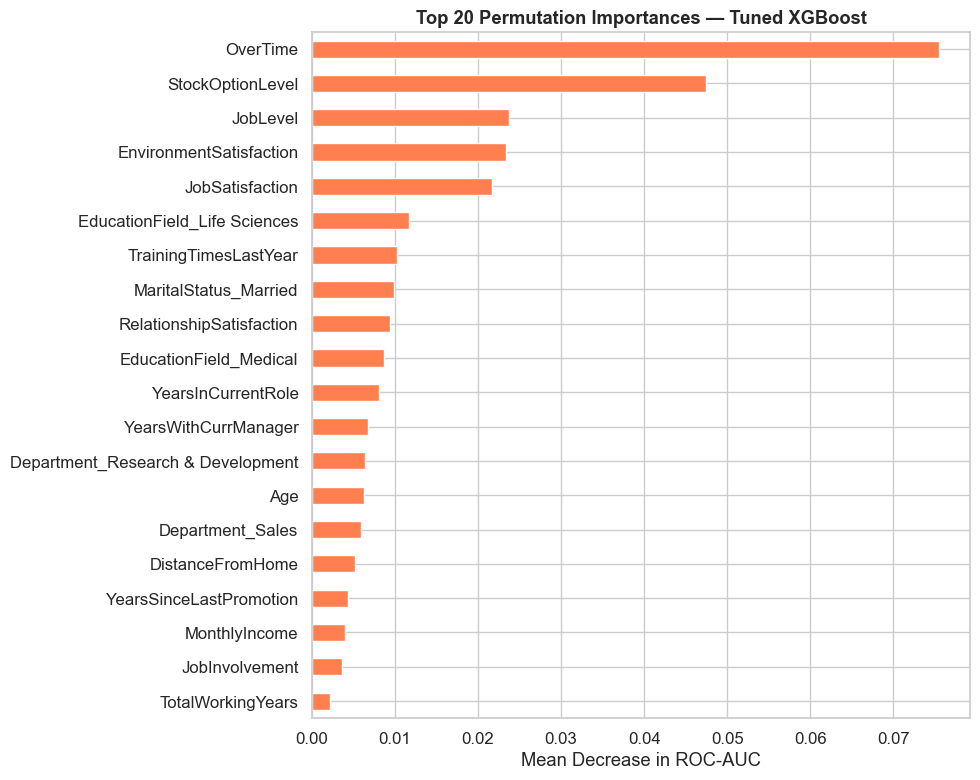

Saved: xgb_04_feature_importance_permutation.png

Top 10 features (Permutation importance):
OverTime                        0.075482
StockOptionLevel                0.047457
JobLevel                        0.023694
EnvironmentSatisfaction         0.023384
JobSatisfaction                 0.021713
EducationField_Life Sciences    0.011658
TrainingTimesLastYear           0.010210
MaritalStatus_Married           0.009906
RelationshipSatisfaction        0.009418
EducationField_Medical          0.008723


In [13]:
# Permutation importance on test set — model-agnostic, more reliable
perm_imp = permutation_importance(
    xgb_tuned, X_test, y_test,
    n_repeats   = 15,
    random_state= RANDOM_STATE,
    scoring     = 'roc_auc',
    n_jobs      = -1
)

perm_series = pd.Series(
    perm_imp.importances_mean,
    index=X_train.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
perm_series.head(20).sort_values().plot(
    kind='barh', ax=ax, color='coral', edgecolor='white'
)
ax.set_title('Top 20 Permutation Importances — Tuned XGBoost', fontweight='bold')
ax.set_xlabel('Mean Decrease in ROC-AUC')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/xgb_04_feature_importance_permutation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: xgb_04_feature_importance_permutation.png')

print('\nTop 10 features (Permutation importance):')
print(perm_series.head(10).to_string())

## 9. Threshold Optimisation

The default decision threshold (0.5) is often suboptimal for imbalanced data.  
We sweep all thresholds and find the one that maximises F1 — same method as Notebook 02.

Default threshold (0.50) F1  : 0.4444
Optimal threshold (0.39) F1: 0.4783


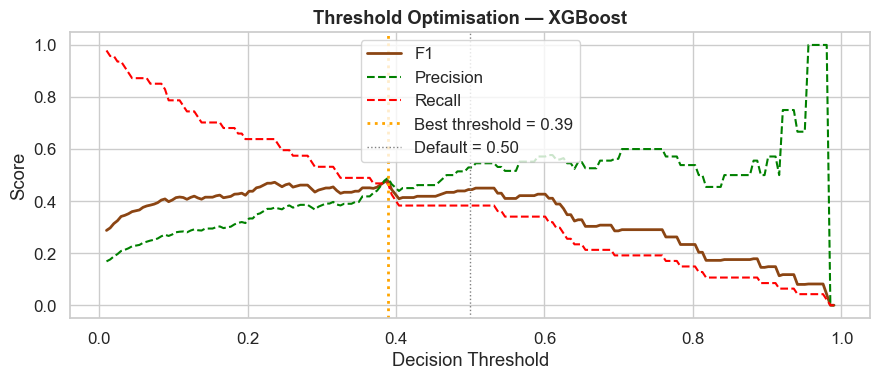

Saved: xgb_05_threshold_optimisation.png


In [14]:
thresholds = np.linspace(0.01, 0.99, 200)
f1_scores, prec_scores, rec_scores = [], [], []

for thr in thresholds:
    preds = (y_proba_tuned >= thr).astype(int)
    f1_scores.append(f1_score(y_test, preds, zero_division=0))
    prec_scores.append(precision_score(y_test, preds, zero_division=0))
    rec_scores.append(recall_score(y_test, preds, zero_division=0))

best_ix  = np.argmax(f1_scores)
best_thr = thresholds[best_ix]
best_f1  = f1_scores[best_ix]

print(f'Default threshold (0.50) F1  : {f1_score(y_test, y_pred_tuned, zero_division=0):.4f}')
print(f'Optimal threshold ({best_thr:.2f}) F1: {best_f1:.4f}')

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds, f1_scores,   label='F1',       color='saddlebrown', lw=2)
ax.plot(thresholds, prec_scores, label='Precision', color='green',      lw=1.5, linestyle='--')
ax.plot(thresholds, rec_scores,  label='Recall',    color='red',        lw=1.5, linestyle='--')
ax.axvline(best_thr, color='orange', lw=2, linestyle=':',
           label=f'Best threshold = {best_thr:.2f}')
ax.axvline(0.5,      color='grey',   lw=1, linestyle=':', label='Default = 0.50')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('Threshold Optimisation — XGBoost', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/xgb_05_threshold_optimisation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: xgb_05_threshold_optimisation.png')

In [15]:
# Evaluate with optimal threshold
y_pred_optimal = (y_proba_tuned >= best_thr).astype(int)

print(f'=== Metrics at Optimal Threshold ({best_thr:.2f}) ===')
print(classification_report(y_test, y_pred_optimal,
      target_names=['No Attrition', 'Attrition']))

# Store for saving below
metrics_optimal = {
    'Accuracy'  : accuracy_score(y_test, y_pred_optimal),
    'Precision' : precision_score(y_test, y_pred_optimal, zero_division=0),
    'Recall'    : recall_score(y_test, y_pred_optimal, zero_division=0),
    'F1-Score'  : f1_score(y_test, y_pred_optimal, zero_division=0),
    'ROC-AUC'   : roc_auc_score(y_test, y_proba_tuned),
    'PR-AUC'    : average_precision_score(y_test, y_proba_tuned),
    'Threshold' : best_thr,
}

=== Metrics at Optimal Threshold (0.39) ===
              precision    recall  f1-score   support

No Attrition       0.90      0.91      0.90       247
   Attrition       0.49      0.47      0.48        47

    accuracy                           0.84       294
   macro avg       0.69      0.69      0.69       294
weighted avg       0.83      0.84      0.84       294



## 10. Save Model & Results Summary

In [16]:
# Save the full tuned pipeline (includes SMOTE step)
model_path = f'{MODELS_DIR}/xgboost_tuned.joblib'
joblib.dump(best_pipeline, model_path)
print(f'Pipeline saved to         : {model_path}')

# Save metrics at default threshold
metrics_df = pd.DataFrame([metrics], index=['XGBoost'])
metrics_df.to_csv(f'{MODELS_DIR}/xgb_metrics.csv')
print(f'Metrics saved to          : {MODELS_DIR}/xgb_metrics.csv')

# Save metrics at optimal threshold
metrics_opt_df = pd.DataFrame([metrics_optimal], index=['XGBoost (optimal thr)'])
metrics_opt_df.to_csv(f'{MODELS_DIR}/xgb_metrics_optimal.csv')
print(f'Optimal metrics saved to  : {MODELS_DIR}/xgb_metrics_optimal.csv')

# Save feature importances (gain) for comparison notebook
feat_imp.to_csv(f'{MODELS_DIR}/xgb_feature_importance.csv', header=['importance'])
print(f'Feature imp saved to      : {MODELS_DIR}/xgb_feature_importance.csv')

Pipeline saved to         : ../models/xgboost_tuned.joblib
Metrics saved to          : ../models/xgb_metrics.csv
Optimal metrics saved to  : ../models/xgb_metrics_optimal.csv
Feature imp saved to      : ../models/xgb_feature_importance.csv


In [17]:
print('=' * 60)
print('       XGBOOST — KEY FINDINGS SUMMARY')
print('=' * 60)

print(f"""
Data (from Notebook 01 preprocessed splits)
  Training samples (SMOTE)   : {X_train.shape[0]}
  Training samples (original): {X_train_orig.shape[0]}
  Test samples               : {X_test.shape[0]}
  Features                   : {X_train.shape[1]}
  Test attrition rate        : {y_test.mean()*100:.1f}%

Model Performance — Tuned XGBoost on Hold-out Test Set (threshold=0.5)
  Accuracy   : {metrics['Accuracy']:.4f}
  Precision  : {metrics['Precision']:.4f}
  Recall     : {metrics['Recall']:.4f}
  F1-Score   : {metrics['F1-Score']:.4f}
  ROC-AUC    : {metrics['ROC-AUC']:.4f}
  PR-AUC     : {metrics['PR-AUC']:.4f}

At Optimal Threshold ({best_thr:.2f})
  F1-Score   : {metrics_optimal['F1-Score']:.4f}
  Precision  : {metrics_optimal['Precision']:.4f}
  Recall     : {metrics_optimal['Recall']:.4f}

Tuning
  Method     : RandomizedSearchCV (80 iter, 5-fold CV, ROC-AUC)
  CV on      : Original unbalanced data via ImbPipeline (no leakage)
  Best CV AUC: {xgb_search.best_score_:.4f}

Top 5 Predictors (Gain importance)""")

for i, (feat, imp) in enumerate(feat_imp.head(5).items(), 1):
    print(f'  {i}. {feat:<35} {imp:.4f}')

print(f"""
Figures saved to : figures/  (5 figures)
Model saved to   : models/xgboost_tuned.joblib
Metrics saved to : models/xgb_metrics.csv

Next step: Run 04_comparison.ipynb
""")
print('=' * 60)

       XGBOOST — KEY FINDINGS SUMMARY

Data (from Notebook 01 preprocessed splits)
  Training samples (SMOTE)   : 1972
  Training samples (original): 1176
  Test samples               : 294
  Features                   : 44
  Test attrition rate        : 16.0%

Model Performance — Tuned XGBoost on Hold-out Test Set (threshold=0.5)
  Accuracy   : 0.8469
  Precision  : 0.5294
  Recall     : 0.3830
  F1-Score   : 0.4444
  ROC-AUC    : 0.7708
  PR-AUC     : 0.4345

At Optimal Threshold (0.39)
  F1-Score   : 0.4783
  Precision  : 0.4889
  Recall     : 0.4681

Tuning
  Method     : RandomizedSearchCV (80 iter, 5-fold CV, ROC-AUC)
  CV on      : Original unbalanced data via ImbPipeline (no leakage)
  Best CV AUC: 0.8040

Top 5 Predictors (Gain importance)
  1. StockOptionLevel                    22.9416
  2. JobLevel                            15.5368
  3. Department_Sales                    14.7750
  4. MaritalStatus_Married               13.8607
  5. JobRole_Sales Executive             10.9